In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('../raw/egypt_real_estate_listings.csv')

print(f"Total properties: {len(df)}")
print(f"\n Columns:")
print(df.columns.tolist())

Total properties: 19924

 Columns:
['url', 'price', 'description', 'location', 'type', 'size', 'bedrooms', 'bathrooms', 'available_from', 'payment_method', 'down_payment']


In [6]:
print("Sample data: ")
print(df.head(5))

Sample data: 
                                                 url       price  \
0  https://www.propertyfinder.eg/en/plp/buy/chale...   8,000,000   
1  https://www.propertyfinder.eg/en/plp/buy/villa...  25,000,000   
2  https://www.propertyfinder.eg/en/plp/buy/chale...  15,135,000   
3  https://www.propertyfinder.eg/en/plp/buy/apart...  12,652,000   
4  https://www.propertyfinder.eg/en/plp/buy/villa...  45,250,000   

                                         description  \
0  OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...   
1  For sale, a villa with immediate delivery in C...   
2  With a down payment of EGP 1,513,000, a fully ...   
3  Own an apartment in New Cairo with a minimal d...   
4  Project: Granville\nLocation: Fifth Settlement...   

                                            location       type  \
0       Swan Lake Gouna, Al Gouna, Hurghada, Red Sea     Chalet   
1   Karmell, New Zayed City, Sheikh Zayed City, Giza      Villa   
2              Azha North, Ras Al Hekma

In [7]:
print("Data Types:")
print(df.dtypes)

Data Types:
url               str
price             str
description       str
location          str
type              str
size              str
bedrooms          str
bathrooms         str
available_from    str
payment_method    str
down_payment      str
dtype: object


In [8]:
print("Missing values: ")
print(df.isnull().sum())

Missing values: 
url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           140
available_from      663
payment_method      541
down_payment      14479
dtype: int64


In [9]:
print("Price stats: ")
print(df['price'].describe)

Price stats: 
<bound method NDFrame.describe of 0         8,000,000
1        25,000,000
2        15,135,000
3        12,652,000
4        45,250,000
            ...    
19919    10,500,000
19920    24,000,000
19921     3,000,000
19922     9,500,000
19923     7,500,000
Name: price, Length: 19924, dtype: str>


In [12]:
print("Property types: ")
print(df['type'].value_counts())

Property types: 
type
Apartment          8355
Chalet             4038
Villa              3570
Townhouse          1335
Twin House          834
Duplex              622
Penthouse           569
iVilla              268
Hotel Apartment     104
Land                 63
Cabin                38
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Bulk Sale Unit        3
Bungalow              1
Name: count, dtype: int64


In [13]:
print('Top locations: ')
print(df['location'].value_counts().head())

Top locations: 
location
Marassi, Sidi Abdel Rahman, North Coast                                                      433
Mountain View iCity, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo     393
Madinaty, Cairo                                                                              368
Hyde Park, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo               359
Palm Hills New Cairo, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo    322
Name: count, dtype: int64


In [18]:
# How many properties have complete data for recommendations?

print(f"Properties with price: {df['price'].notna().sum():,}")

print(f"Properties with description: {df['description'].notna().sum():,}")

print(f"Properties with location: {df['location'].notna().sum():,}")

print(f"Properties with bedroom count: {df['bedrooms'].notna().sum():,}")

print(f"Properties with all: {df[['price', 'description', 'location', 'bedrooms']].notna().all(axis=1).sum():,}")

Properties with price: 19,385
Properties with description: 19,846
Properties with location: 19,833
Properties with bedroom count: 19,780
Properties with all: 19,321


In [ ]:
# Are descriptions good enough for AI embeddings?

df['desc_length'] = df['description'].fillna('').str.len()

In [23]:
print(f"Empty descriptions: {(df['desc_length'] == 0 ).sum()}")
print(f"Very short (<50 characters): {(df['desc_length'] < 50 ).sum()}")
print(f"Good length (>100 characters): {df['desc_length'] > 100 }.sum()")
print(f"Average: {df['desc_length'].mean():.0f} chars")



Empty descriptions: 78
Very short (<50 characters): 83
Good length (>100 characters): 0        True
1        True
2        True
3        True
4        True
         ... 
19919    True
19920    True
19921    True
19922    True
19923    True
Name: desc_length, Length: 19924, dtype: bool.sum()
Average: 922 chars


In [27]:
# Which locations have the best coverage?

print(f"Total unique locations: {df['location'].nunique()}")

df['city'] = df['location'].str.split(',').str[-1].str.strip()

print("\nTop cities:")

print(df['city'].value_counts().head(10))

print("\nCairo Districts")

cairo_props = df[df['city'].str.contains('Cairo', na = False)]
print(f"Cairo properties: {len(cairo_props):,}")

cairo_props['district'] = cairo_props['location'].str.split(',').str[0]
print(cairo_props['district'].value_counts().head(10))

Total unique locations: 1535

Top cities:
city
Cairo           7610
North Coast     5246
Giza            4276
Red Sea         1598
Suez             601
Alexandria       385
Qalyubia          58
South Sainai      28
Al Daqahlya       11
Matrouh            6
Name: count, dtype: int64

Cairo Districts
Cairo properties: 7,610
district
Mountain View iCity        393
Madinaty                   368
Hyde Park                  359
Palm Hills New Cairo       322
Sarai                      267
Mivida                     242
Taj City                   225
Mountain View Hyde Park    218
El Patio Oro               175
City Gate                  160
Name: count, dtype: int64


In [28]:
# Popular property types


print("\nQ5: PROPERTY TYPES")
print(df['type'].value_counts())


print("\nTypes with 100+ properties:")
type_counts = df['type'].value_counts()
for prop_type, count in type_counts.items():
    if count >= 100:
        print(f"  {prop_type}: {count:,}")


Q5: PROPERTY TYPES
type
Apartment          8355
Chalet             4038
Villa              3570
Townhouse          1335
Twin House          834
Duplex              622
Penthouse           569
iVilla              268
Hotel Apartment     104
Land                 63
Cabin                38
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Bulk Sale Unit        3
Bungalow              1
Name: count, dtype: int64

Types with 100+ properties:
  Apartment: 8,355
  Chalet: 4,038
  Villa: 3,570
  Townhouse: 1,335
  Twin House: 834
  Duplex: 622
  Penthouse: 569
  iVilla: 268
  Hotel Apartment: 104


In [30]:
# Most popular amenities and keywords

print("\n Common keywords in descriptions")

all_descriptions = ' '.join(df['description'].fillna('').str.lower())

keywords = ['pool', 'gym', 'parking', 'garden', 'balcony', 'view', 'security', 
            'elevator', 'furnished', 'kitchen', 'beach', 'compound']

for keyword in keywords:
    count = all_descriptions.count(keyword)
    print(f"  {keyword}: {count:,} mentions")


 Common keywords in descriptions
  pool: 7,135 mentions
  gym: 2,528 mentions
  parking: 2,175 mentions
  garden: 8,592 mentions
  balcony: 310 mentions
  view: 20,979 mentions
  security: 4,483 mentions
  elevator: 930 mentions
  furnished: 2,311 mentions
  kitchen: 6,141 mentions
  beach: 6,567 mentions
  compound: 15,732 mentions


In [31]:
# Q8: Overall data quality score
print("\nQ8: DATA COMPLETENESS SCORE")

critical_cols = ['price', 'description', 'location', 'type', 'bedrooms']
df['completeness'] = df[critical_cols].notna().sum(axis=1) / len(critical_cols) * 100

print(f"100% complete: {(df['completeness'] == 100).sum():,} properties")
print(f"80%+ complete: {(df['completeness'] >= 80).sum():,} properties")
print(f"60%+ complete: {(df['completeness'] >= 60).sum():,} properties")
print(f"Average completeness: {df['completeness'].mean():.1f}%")


Q8: DATA COMPLETENESS SCORE
100% complete: 19,321 properties
80%+ complete: 19,829 properties
60%+ complete: 19,847 properties
Average completeness: 99.1%


In [35]:
# Remove commas, convert to float first (allows NaN), then to int
df['price_clean'] = df['price'].str.replace(',', '').astype(float).astype('Int64')

print(df['price_clean'].head(10))

# Check how many are missing
print(f"\nMissing prices: {df['price_clean'].isna().sum()}")

0     8000000
1    25000000
2    15135000
3    12652000
4    45250000
5    19760000
6     9000000
7     2770000
8    13200000
9    22300000
Name: price_clean, dtype: Int64

Missing prices: 539


In [36]:
# Look at size column
print("First 10 sizes (RAW):")
print(df['size'].head(10))

First 10 sizes (RAW):
0       732 sqft / 68 sqm
1    2,368 sqft / 220 sqm
2    1,270 sqft / 118 sqm
3    1,787 sqft / 166 sqm
4    4,306 sqft / 400 sqm
5    1,356 sqft / 126 sqm
6    2,820 sqft / 262 sqm
7    3,983 sqft / 370 sqm
8    2,368 sqft / 220 sqm
9    2,099 sqft / 195 sqm
Name: size, dtype: str


In [38]:
df['size_clean'] = df['size'].str.extract(r'(\d+)\s*sqm')[0].astype('Int64')

print(df['size_clean'].head(10))

print(f"\nMissing sizes: {df['size_clean'].isna().sum()}")

0     68
1    220
2    118
3    166
4    400
5    126
6    262
7    370
8    220
9    195
Name: size_clean, dtype: Int64

Missing sizes: 77


In [39]:
# Look at bedrooms column
print("First 10 bedrooms (RAW):")
print(df['bedrooms'].head(10))

First 10 bedrooms (RAW):
0    1+ Maid
1          4
2          2
3          3
4          7
5          3
6          4
7    5+ Maid
8          3
9    3+ Maid
Name: bedrooms, dtype: str


In [41]:
# Extract bedroom number
df['bedrooms_clean'] = df['bedrooms'].str.extract(r'(\d+)')[0].astype('Int64')

# Create a "has_maid_room" boolean column
df['has_maid_room'] = df['bedrooms'].str.contains('Maid', na=False)

print("\nBEDROOMS (NUMBER):")
print(df['bedrooms_clean'].head(10))

print("\nHAS MAID ROOM:")
print(df['has_maid_room'].head(10))

print(f"\nProperties with maid room: {df['has_maid_room'].sum()}")


BEDROOMS (NUMBER):
0    1
1    4
2    2
3    3
4    7
5    3
6    4
7    5
8    3
9    3
Name: bedrooms_clean, dtype: Int64

HAS MAID ROOM:
0     True
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8    False
9     True
Name: has_maid_room, dtype: bool

Properties with maid room: 9341


In [42]:
# Look at bathrooms
print("First 10 bathrooms (RAW):")
print(df['bathrooms'].head(10))

First 10 bathrooms (RAW):
0    1
1    4
2    2
3    2
4    7
5    2
6    5
7    5
8    3
9    2
Name: bathrooms, dtype: str


In [44]:
# Extract number (handles "7+" → 7)
df['bathrooms_clean'] = df['bathrooms'].str.extract(r'(\d+)')[0].astype('Int64')

print("\nAFTER:")
print(df['bathrooms_clean'].head(20))

print(f"\nMissing bathrooms: {df['bathrooms_clean'].isna().sum()}")


AFTER:
0     1
1     4
2     2
3     2
4     7
5     2
6     5
7     5
8     3
9     2
10    4
11    2
12    1
13    3
14    1
15    3
16    1
17    4
18    1
19    3
Name: bathrooms_clean, dtype: Int64

Missing bathrooms: 145


In [45]:
print("="*60)
print("CLEANING SUMMARY")
print("="*60)

cleaned_cols = {
    'price_clean': 'Price (EGP)',
    'size_clean': 'Size (sqm)',
    'bedrooms_clean': 'Bedrooms',
    'bathrooms_clean': 'Bathrooms',
    'has_maid_room': 'Maid Room'
}

for col, label in cleaned_cols.items():
    if col in df.columns:
        missing = df[col].isna().sum()
        total = len(df)
        print(f"{label:20s} | Missing: {missing:5,} ({missing/total*100:5.1f}%)")

print("="*60)

# How many rows have ALL critical data?
critical = df[['price_clean', 'size_clean', 'bedrooms_clean', 'bathrooms_clean']].notna().all(axis=1)
print(f"\n✅ Properties with ALL data complete: {critical.sum():,}")
print(f"❌ Properties with missing data: {(~critical).sum():,}")

CLEANING SUMMARY
Price (EGP)          | Missing:   539 (  2.7%)
Size (sqm)           | Missing:    77 (  0.4%)
Bedrooms             | Missing:   472 (  2.4%)
Bathrooms            | Missing:   145 (  0.7%)
Maid Room            | Missing:     0 (  0.0%)

✅ Properties with ALL data complete: 18,991
❌ Properties with missing data: 933


In [46]:
# Select only the columns we need
df_final = df[[
    'price_clean',
    'size_clean', 
    'bedrooms_clean',
    'bathrooms_clean',
    'has_maid_room',
    'description',
    'location',
    'type',
    'url'
]].rename(columns={
    'price_clean': 'price',
    'size_clean': 'size',
    'bedrooms_clean': 'bedrooms',
    'bathrooms_clean': 'bathrooms'
})

# Remove rows with missing critical data
df_final = df_final.dropna(subset=['price', 'size', 'bedrooms', 'bathrooms'])

print(f"📊 FINAL DATASET: {len(df_final):,} properties")
print(f"\n📋 Columns:")
print(df_final.columns.tolist())

# Save to processed folder
df_final.to_csv('../processed/egyptian_properties_clean.csv', index=False)

print(f"\n💾 Saved to: ../processed/egyptian_properties_clean.csv")

# Show sample
print("\n🔍 Sample of cleaned data:")
df_final.head(3)

📊 FINAL DATASET: 18,991 properties

📋 Columns:
['price', 'size', 'bedrooms', 'bathrooms', 'has_maid_room', 'description', 'location', 'type', 'url']

💾 Saved to: ../processed/egyptian_properties_clean.csv

🔍 Sample of cleaned data:


,price,size,bedrooms,bathrooms,has_maid_room,description,location,type,url
0,8000000,68,1,1,True,OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,https://www.propertyfinder.eg/en/plp/buy/chale...
1,25000000,220,4,4,False,"For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,https://www.propertyfinder.eg/en/plp/buy/villa...
2,15135000,118,2,2,False,"With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,https://www.propertyfinder.eg/en/plp/buy/chale...


In [51]:
df = pd.read_csv('../processed/egyptian_properties_clean.csv')

print(f"📊 Loaded {len(df):,} properties")
print(f"Price type: {df['price'].dtype}")
print(df.head(3))

📊 Loaded 18,991 properties
Price type: int64
      price  size  bedrooms  bathrooms  has_maid_room  \
0   8000000    68         1          1           True   
1  25000000   220         4          4          False   
2  15135000   118         2          2          False   

                                         description  \
0  OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...   
1  For sale, a villa with immediate delivery in C...   
2  With a down payment of EGP 1,513,000, a fully ...   

                                           location    type  \
0      Swan Lake Gouna, Al Gouna, Hurghada, Red Sea  Chalet   
1  Karmell, New Zayed City, Sheikh Zayed City, Giza   Villa   
2             Azha North, Ras Al Hekma, North Coast  Chalet   

                                                 url  
0  https://www.propertyfinder.eg/en/plp/buy/chale...  
1  https://www.propertyfinder.eg/en/plp/buy/villa...  
2  https://www.propertyfinder.eg/en/plp/buy/chale...  


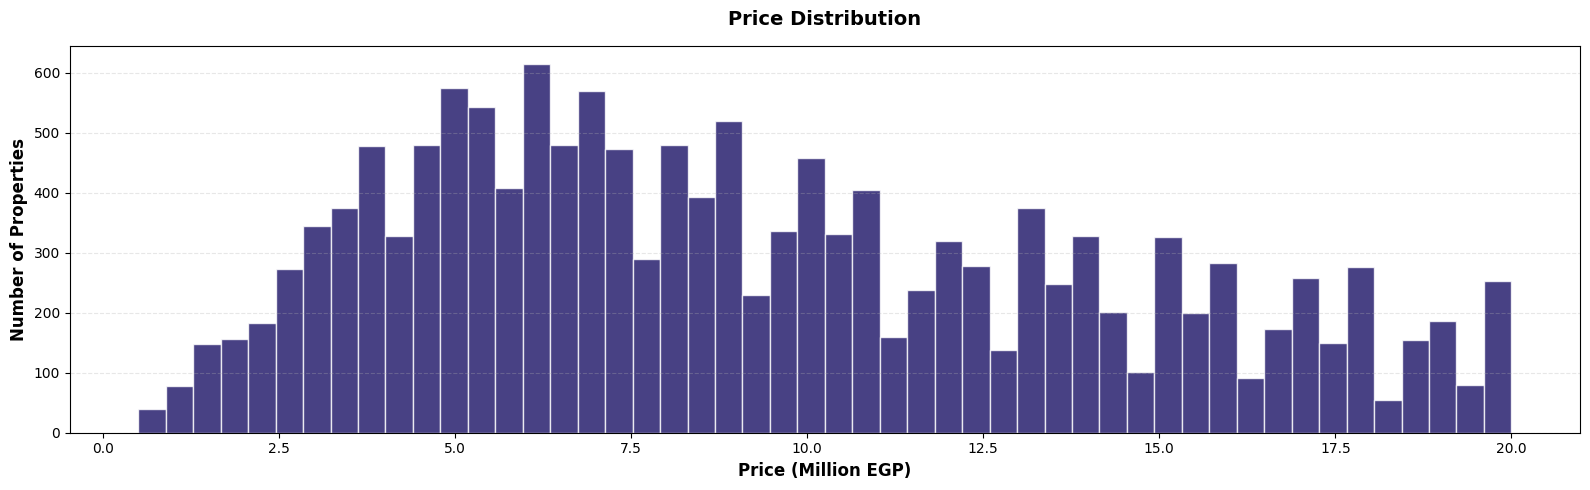

In [54]:
# Data visualizations

fig = plt.figure(figsize=(16,5))

prices_viz = df[(df['price'] >= 500000) & (df['price'] <= 20000000)]


# Clean histogram
plt.hist(prices_viz['price'] / 1000000, bins=50, color='#1A1265', 
         edgecolor='white', alpha=0.8)

plt.xlabel('Price (Million EGP)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Properties', fontsize=12, fontweight='bold')
plt.title('Price Distribution', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

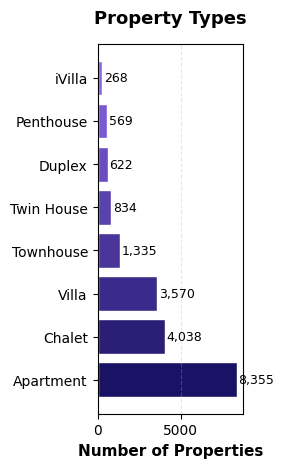

In [48]:
# Property Types

plt.subplot(1, 3, 2)

type_counts = df['type'].value_counts().head(8)
colors = ['#1A1265', '#2A1E77', '#3A2A89', '#4A369B', '#5A42AD', '#6A4EBF', '#7A5AD1', '#8A66E3']

plt.barh(range(len(type_counts)), type_counts.values, color=colors, edgecolor='white')
plt.yticks(range(len(type_counts)), type_counts.index)
plt.xlabel('Number of Properties', fontsize=11, fontweight='bold')
plt.title('Property Types', fontsize=13, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add count labels
for i, v in enumerate(type_counts.values):
    plt.text(v + 100, i, f'{v:,}', va='center', fontsize=9)


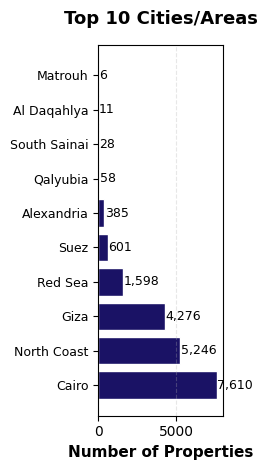

In [49]:
plt.subplot(1, 3, 3)

# Extract city (last part after comma)
df['city'] = df['location'].str.split(',').str[-1].str.strip()
top_cities = df['city'].value_counts().head(10)

plt.barh(range(len(top_cities)), top_cities.values, color='#1A1265', edgecolor='white')
plt.yticks(range(len(top_cities)), top_cities.index, fontsize=9)
plt.xlabel('Number of Properties', fontsize=11, fontweight='bold')
plt.title('Top 10 Cities/Areas', fontsize=13, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add count labels
for i, v in enumerate(top_cities.values):
    plt.text(v + 20, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\marwa\AppData\Local\Temp\ipykernel_8764\141683793.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(city_prices, labels=top_cities, patch_artist=True)


(0.0, 20.0)

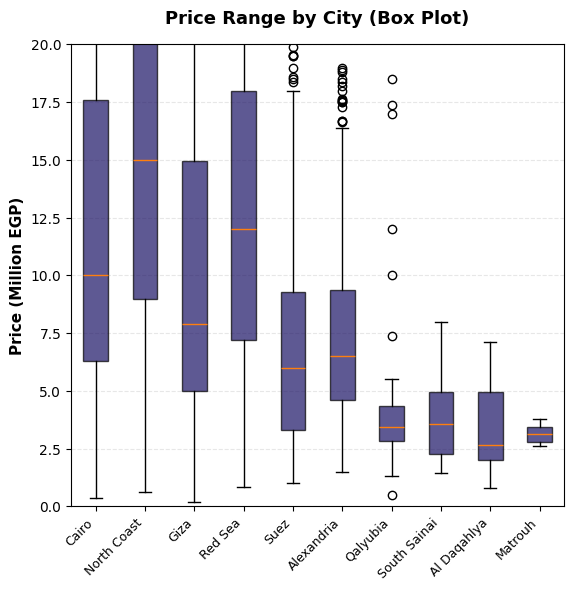

In [57]:
# Get top 10 cities
df['city'] = df['location'].str.split(',').str[-1].str.strip()
top_cities = df['city'].value_counts().head(10).index

# Filter data for top cities only
df_top_cities = df[df['city'].isin(top_cities)]

# Create figure
plt.figure(figsize=(14, 6))

# ============================================================
# OPTION 1: BOX PLOT (Shows price ranges per city)
# ============================================================
plt.subplot(1, 2, 1)

# Prepare data for box plot
city_prices = [df[df['city'] == city]['price'] / 1000000 for city in top_cities]

bp = plt.boxplot(city_prices, labels=top_cities, patch_artist=True)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('#1A1265')
    patch.set_alpha(0.7)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Price (Million EGP)', fontsize=11, fontweight='bold')
plt.title('Price Range by City (Box Plot)', fontsize=13, fontweight='bold', pad=15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, 20)  # Focus on 0-20M range

In [ ]:
df['price_per_sqm'] = (df['price'] / df['size']).round(0).astype(int)

df['city'] = df['location'].str.split(',').str[-1].str.strip()

df['neighborhood'] = df['location'].str.split(',').str[0].str.strip()

# 4. PRICE CATEGORY
max_price = df['price'].max() + 1
df['price_category'] = pd.cut(df['price'], 
                               bins=[0, 3000000, 10000000, max_price],
                               labels=['Budget', 'Mid-Range', 'Luxury'])

# 6. BEDROOM CATEGORY
max_beds = df['bedrooms'].max() + 1
df['bedroom_category'] = pd.cut(df['bedrooms'],
                                 bins=[0, 2, 3, 4, max_beds],
                                 labels=['Studio/1BR', '2BR', '3BR', '4BR+'])

print("\n NEW FEATURES CREATED!")
print("\n SAMPLE DATA:")
print(df[['price', 'size', 'price_per_sqm', 'city', 'price_category']].head())

print("\n TOP 10 CITIES:")
print(df['city'].value_counts().head(10))

print("\n PRICE CATEGORY DISTRIBUTION:")
print(df['price_category'].value_counts())

# Save
df.to_csv('../processed/egyptian_properties_features.csv', index=False)
print(f"\n Saved to: ../processed/egyptian_properties_features.csv")
print(f"   Total rows: {len(df):,}")
print(f"   Total columns: {len(df.columns)}")



✅ NEW FEATURES CREATED!

📊 SAMPLE DATA:
      price  size  price_per_sqm         city price_category
0   8000000    68         117647      Red Sea      Mid-Range
1  25000000   220         113636         Giza         Luxury
2  15135000   118         128263  North Coast         Luxury
3  12652000   166          76217        Cairo         Luxury
4  45250000   400         113125        Cairo         Luxury

🏙️ TOP 10 CITIES:
city
Cairo           7322
North Coast     5041
Giza            4081
Red Sea         1438
Suez             586
Alexandria       382
Qalyubia          58
South Sainai      24
Al Daqahlya       11
Matrouh            6
Name: count, dtype: int64

💰 PRICE CATEGORY DISTRIBUTION:
price_category
Luxury       9785
Mid-Range    8066
Budget       1112
Name: count, dtype: int64

💾 Saved to: ../processed/egyptian_properties_features.csv
   Total rows: 18,963
   Total columns: 14
